# Load modules

In [34]:
import os
import xarray as xr
import pyproj
import numpy as np
from glob import glob 
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

import functions

# Define directories

In [40]:
path_current = os.getcwd()
path_data = os.path.join(path_current, 'Fields_INALT60/')
path_OW = path_data+'OW_proba/'

main_path = '/Users/solangecoadou/Desktop/Desktop/Thesis/'
swot_dir= main_path+'GRL_2026_SWOT_SQG/DATA/Swot_science_phase/'

path_save_data = os.path.join(path_current, 'SWOT_analysis/Science_phase/')

# Grid eSQG model

In [11]:
bathy = xr.open_dataset(path_data+'bathy_INALT60.nc')

lon_c=15.7
lat_c=-37.8

pos_west,pos_east,pos_south,pos_north  = lon_c-2,lon_c+2,lat_c-2,lat_c+2

bathy_region=bathy.where((bathy.nav_lat>pos_south-1.2) & (bathy.nav_lat<pos_north+1.2) & (bathy.nav_lon>pos_west-1.2) & (bathy.nav_lon<pos_east+1.2), drop=True)

dx=2
lon_grid=bathy_region.nav_lon
lat_grid=bathy_region.nav_lat

#Define the grid
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)
    
#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)

#Make square
size_x=len(lon2[0,:])
size_y=len(lon2[:,0])

if size_y>size_x:
    delta_points=size_y-size_x
    lon2 = lon2[:size_x,:]
    lat2 = lat2[:size_x,:]
else:
    delta_points=size_x-size_y
    lon2 = lon2[:,:size_y]
    lat2 = lat2[:,:size_y]

lon2, lat2 = lon2[50:-50,50:-50], lat2[50:-50,50:-50]

# Save reconstruction by pass number

In [ ]:
##Add SQG boxes
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)
pos_west,pos_east,pos_south,pos_north  = lonmin,lonmax,latmin,latmax

depth_list = np.array([4.7679895e-01, 1.5707064e+00, 2.8554180e+00, 4.3355064e+00,
       6.0156703e+00, 7.9007444e+00, 9.9957113e+00, 1.2305715e+01,
       1.4836073e+01, 1.7592300e+01, 2.0580124e+01, 2.3805506e+01,
       2.7274673e+01, 3.0994144e+01, 3.4970764e+01, 3.9211739e+01,
       4.3724689e+01, 4.8517693e+01, 5.3599339e+01, 5.8978794e+01,
       6.4665886e+01, 7.0671165e+01, 7.7006004e+01, 8.3682709e+01,
       9.0714615e+01, 9.8116249e+01, 1.0590342e+02, 1.1409344e+02,
       1.2270523e+02, 1.3175960e+02, 1.4127936e+02, 1.5128963e+02,
       1.6181805e+02, 1.7289508e+02, 1.8455423e+02, 1.9683240e+02,
       2.0977017e+02, 2.2341211e+02, 2.3780708e+02, 2.5300858e+02,
       2.6907489e+02, 2.8606949e+02, 3.0406100e+02, 3.2312344e+02,
       3.4333621e+02, 3.6478378e+02, 3.8755551e+02, 4.1174518e+02,
       4.3745007e+02, 4.6477032e+02, 4.9380743e+02, 5.2466309e+02,
       5.5743713e+02, 5.9222620e+02, 6.2912128e+02, 6.6820563e+02,
       7.0955292e+02, 7.5322528e+02, 7.9927124e+02, 8.4772443e+02,
       8.9860266e+02, 9.5190729e+02], dtype=np.float32)

cycles = np.arange(1,48)
pass_numbers = np.array([305,320,333,348,361,376,583,14,27,42,55,70])

for p in pass_numbers:
    initialisation=1
    for c, ic in zip(cycles, np.arange(len(cycles))):
        if c<10:
            cstr = '_00'+ str(c)
        else:
            cstr = '_0'+ str(c)
        if p<10:
            pstr = '_00'+ str(p)
        elif p<100:
            pstr = '_0'+ str(p)
        else:
            pstr = '_'+ str(p)
        if len([x for x in glob(swot_dir+'*'+cstr+pstr+'*.nc')])>0:
            file_2_read=[x for x in glob(swot_dir+'*'+cstr+pstr+'*.nc')][0]
            field='vorticity'
            zeta_sqg, mask_zeta, lon_zeta, lat_zeta = compute_sqg_swot(depth_list, file_2_read, field)
            field='velocity'
            w_sqg, mask_w, lon_w, lat_w = compute_sqg_swot(depth_list, file_2_read, field)
            field='strain'
            strain_sqg, mask_strain, lon_strain, lat_strain = compute_sqg_swot(depth_list, file_2_read, field)            
            if initialisation:
                zeta_store = np.zeros([len(cycles), len(depth_list) ,lon_w.shape[0],lon_w.shape[1]])+np.nan
                strain_store = np.zeros([len(cycles), len(depth_list) ,lon_w.shape[0],lon_w.shape[1]])+np.nan
                w_store = np.zeros([len(cycles), len(depth_list) ,lon_w.shape[0],lon_w.shape[1]])+np.nan
                time_store = np.zeros([len(cycles), lon_w.shape[0]],dtype='datetime64[ns]') #Set to 1970/01/01
                lon = lon_w
                lat = lat_w
                initialisation=0

            if len(mask_zeta)>1:
            
                #Zeta
                rm_col = np.concatenate([np.arange(4),np.arange(24,33), np.arange(54,57)])
    
                field = zeta_sqg
                field[:,mask_zeta]=np.nan
                field[:,:,rm_col]=np.nan
                zeta_store[ic,:,:,:] = field
                
                #W
                field = w_sqg
                field[:,mask_w]=np.nan
                field[:,:,rm_col]=np.nan
                w_store[ic,:,:,:] = field
                
                #strain
                field = strain_sqg
                field[:,mask_strain]=np.nan
                field[:,:,rm_col]=np.nan
                strain_store[ic,:,:,:] = field
                
                latmin, latmax = np.min(latBIG)-.2, np.max(latBIG)+.2
                lonmin, lonmax = np.min(lonBIG)-.2, np.max(lonBIG)+.2
                pos_west,pos_east,pos_south,pos_north  = lonmin,lonmax,latmin,latmax

                #Cut data around the region of interest
                swot = xr.open_dataset(file_2_read)
                id_select = np.where((swot.longitude>pos_west) & (swot.longitude<pos_east) & (swot.latitude>pos_south) & (swot.latitude<pos_north))[0]
                swot = swot.isel(num_lines=slice(id_select[0], id_select[-1]))
                
                time_store[ic,:] = swot.time.values[6:-6]
                
    #Turn nan every points outside of the region
    
    id_unselect_row, id_unselect_col = np.where((lon<pos_west) | (lon>pos_east) | (lat<pos_south) | (lat>pos_north))
    zeta_store[:,:,id_unselect_row, id_unselect_col]=np.nan
    w_store[:,:,id_unselect_row, id_unselect_col]=np.nan
    strain_store[:,:,id_unselect_row, id_unselect_col]=np.nan
           
    ds_to_save = xr.Dataset(
                data_vars=dict(
                    zeta=(["cycle", "depth", "num_lines", "num_pixels"], zeta_store),
                    strain=(["cycle", "depth", "num_lines", "num_pixels"], strain_store),
                    w=(["cycle", "depth", "num_lines", "num_pixels"], w_store),
                    time=(["cycle", "num_lines"], time_store),
                    lon=(["num_lines", "num_pixels"], lon),
                    lat=(["num_lines", "num_pixels"], lat)
                ),
                coords=dict(
                    cycle=("cycle", cycles),
                    num_lines=("num_lines", np.arange(lon.shape[0])),
                    num_pixels=("num_pixels", np.arange(lon.shape[1])),
                    depth=("depth", depth_list)

                ) 
            )
    
    ds_to_save.to_netcdf(path=path_save_data+'pass_number_'+str(p)+'.nc')

# Save SSH field by pass number

In [ ]:
for p in pass_numbers:
    initialisation=1
    for c, ic in zip(cycles, np.arange(len(cycles))):
        if c<10:
            cstr = '_00'+ str(c)
        else:
            cstr = '_0'+ str(c)
        if p<10:
            pstr = '_00'+ str(p)
        elif p<100:
            pstr = '_0'+ str(p)
        else:
            pstr = '_'+ str(p)
        if len([x for x in glob(swot_dir+'*'+cstr+pstr+'*.nc')])>0:
            file_2_read=[x for x in glob(swot_dir+'*'+cstr+pstr+'*.nc')][0]
            swot = process_SSH_before_computing_derivatives(file_2_read, reduce=True)
            if initialisation:
                adt = swot.ssh_interp.data
                ssh_store = np.zeros([len(cycles),  adt.shape[0],adt.shape[1]-12])+np.nan
                initialisation=0
            
            #Filter SSH 
            dx = 2
            cutoff_lenght = 40
            hws=int(2*(cutoff_lenght/dx)-1)
            cutoff_frequency = 1/(cutoff_lenght/dx)
            field_filter = filter_convolution2d(LanczosKernel(cutoff_frequency, hws),swot.ssh_interp.data)
            mask_ssh = swot.mask_nan.data
            field_filter[mask_ssh]=np.nan
            field_filter=field_filter[:,6:-6]
            rm_col = np.concatenate([np.arange(4),np.arange(24,33), np.arange(54,57)])
            field_filter[:,rm_col]=np.nan
            ssh_store[ic,:,:] = field_filter
            
    lon = swot.longitude.data[:,6:-6]
    lat = swot.latitude.data[:,6:-6]
               
    ds_to_save = xr.Dataset(
                data_vars=dict(
                    ssh_store=(["cycle","num_lines", "num_pixels"], ssh_store),
                    lon=(["num_lines", "num_pixels"], lon),
                    lat=(["num_lines", "num_pixels"], lat)
                ),
                coords=dict(
                    cycle=("cycle", cycles),
                    num_lines=("num_lines", np.arange(lon.shape[0])),
                    num_pixels=("num_pixels", np.arange(lon.shape[1]))

                ) 
            )
    
    ds_to_save.to_netcdf(path=path_save_data+'ssh_'+str(p)+'.nc')


# Save RMS profiles of w for each reconstructed maps (2 per cycle)

In [23]:
cycles = np.arange(1,47)
pass_number_1 = np.array([305,320,333,348,361,376])
pass_number_2 = np.array([583,14,27,42,55,70])
t=0
for c in cycles:
    if c>1:
        file_2_read = []
        for p in pass_number_2:
            pstr = str(p)
            file_2_read.append([x for x in glob(path_save_data+'pass_number_'+pstr+'.nc')][0])
        for ff in range(len(file_2_read)):
            data = xr.open_dataset(file_2_read[ff])
            if ff==0:
                zeta_combine = data.sel(cycle=c-1).zeta.stack(xy=["num_lines", "num_pixels"])
                w_combine = data.sel(cycle=c-1).w.stack(xy=["num_lines", "num_pixels"])
                strain_combine = data.sel(cycle=c-1).strain.stack(xy=["num_lines", "num_pixels"])
                time_combine = data.sel(cycle=c-1).time

            else:
                zeta_cycle = data.sel(cycle=c).zeta.stack(xy=["num_lines", "num_pixels"])
                w_cycle = data.sel(cycle=c).w.stack(xy=["num_lines", "num_pixels"])
                strain_cycle = data.sel(cycle=c).strain.stack(xy=["num_lines", "num_pixels"]) 
                time_cycle = data.sel(cycle=c).time

                zeta_combine = xr.concat((zeta_combine,zeta_cycle), dim='xy')
                w_combine = xr.concat((w_combine,w_cycle), dim='xy')
                strain_combine = xr.concat((strain_combine,strain_cycle), dim='xy')

                time_combine = xr.concat((time_combine,time_cycle), dim='num_lines')
                
        #Remove Nans:
        xy_select = np.where(np.isnan(zeta_combine.isel(depth=0))==0)[0]
        
        time_select = time_combine.where(time_combine.dt.year>1970, drop=True)
    
        if len(time_select)>0:
        
            ds_to_save = xr.Dataset(
                        data_vars=dict(
                            zeta=(["z", "xy"], zeta_combine.isel(xy=xy_select).values),
                            w=(["z", "xy"], w_combine.isel(xy=xy_select).values),
                            strain=(["z", "xy"], strain_combine.isel(xy=xy_select).values)
            
                        ),
                        coords=dict(
                            z=("z", depth_list),
                            time=("time", [time_select.mean().values])
                        ) 
                    )
            
                    
            ds_to_save.to_netcdf(path=path_save_data+'dynamics_'+str(t)+'.nc')
            
            RMS_velocity=(w_combine.isel(xy=xy_select)**2).mean(dim='xy')**.5

            ds_to_save = xr.Dataset(
                        data_vars=dict(
                            RMS_velocity=(["z"], RMS_velocity.values)
        
                        ),
                        coords=dict(
                            z=("z", depth_list),
                            time=("time", [time_select.mean().values])
                        ) 
                    )
            
            ds_to_save.to_netcdf(path=path_save_data+'RMS_'+str(t)+'.nc')

            t+=1
    
    file_2_read = []
    for p in pass_number_1:
        pstr = str(p)
        file_2_read.append([x for x in glob(path_save_data+'pass_number_'+pstr+'.nc')][0])
    for ff in range(len(file_2_read)):
        data = xr.open_dataset(file_2_read[ff])
        if ff==0:
            zeta_combine = data.sel(cycle=c).zeta.stack(xy=["num_lines", "num_pixels"])
            w_combine = data.sel(cycle=c).w.stack(xy=["num_lines", "num_pixels"])
            strain_combine = data.sel(cycle=c).strain.stack(xy=["num_lines", "num_pixels"])

            time_combine = data.sel(cycle=c).time
        else:
            zeta_cycle = data.sel(cycle=c).zeta.stack(xy=["num_lines", "num_pixels"])
            w_cycle = data.sel(cycle=c).w.stack(xy=["num_lines", "num_pixels"]) 
            strain_cycle = data.sel(cycle=c).strain.stack(xy=["num_lines", "num_pixels"]) 

            time_cycle = data.sel(cycle=c).time
               
            zeta_combine = xr.concat((zeta_combine,zeta_cycle), dim='xy')
            w_combine = xr.concat((w_combine,w_cycle), dim='xy')
            strain_combine = xr.concat((strain_combine,strain_cycle), dim='xy')

            time_combine = xr.concat((time_combine,time_cycle), dim='num_lines')
    
    #Remove Nans:
    xy_select = np.where(np.isnan(zeta_combine.isel(depth=0))==0)[0]
    
    time_select = time_combine.where(time_combine.dt.year>1970, drop=True)
    
    if len(time_select)>0:
    
        ds_to_save = xr.Dataset(
                    data_vars=dict(
                        zeta=(["z", "xy"], zeta_combine.isel(xy=xy_select).values),
                        w=(["z", "xy"], w_combine.isel(xy=xy_select).values),
                        strain=(["z", "xy"], strain_combine.isel(xy=xy_select).values)
        
                    ),
                    coords=dict(
                        z=("z", depth_list),
                        time=("time", [time_select.mean().values])
                    ) 
                )
        
        ds_to_save.to_netcdf(path=path_save_data+'dynamics_'+str(t)+'.nc')
        
        RMS_velocity=(w_combine.isel(xy=xy_select)**2).mean(dim='xy')**.5

        ds_to_save = xr.Dataset(
                    data_vars=dict(
                        RMS_velocity=(["z"], RMS_velocity.values)
    
                    ),
                    coords=dict(
                        z=("z", depth_list),
                        time=("time", [time_select.mean().values])
                    ) 
                )
        
        ds_to_save.to_netcdf(path=path_save_data+'RMS_'+str(t)+'.nc')
            
        t+=1

# Plot figure

### Compute SSH spatial mean

In [29]:
for p in pass_numbers:    
    ds_maps = xr.open_dataset(path_save_data+'ssh_'+str(p)+'.nc')
    data_temporal_mean=np.nanmedian(ds_maps.ssh_store, axis=0)
    if p==pass_numbers[0]:
        data_combine = data_temporal_mean
    else:
        data_combine=np.concatenate((data_combine, data_temporal_mean))
spatial_mean = np.nanmean(data_combine)

/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_89465/405516647.py:3: RuntimeWarning: All-NaN slice encountered
  data_temporal_mean=np.nanmedian(ds_maps.ssh_store, axis=0)


### Read data

In [43]:
map_model = xr.open_dataset(path_data+'INALT60_mean_w.nc')
ssh_model = xr.open_dataset(path_data+'INALT60_mean_ssh.nc')
files_OW = [x for x in glob(path_OW+'*.nc')] 
files_OW.sort()

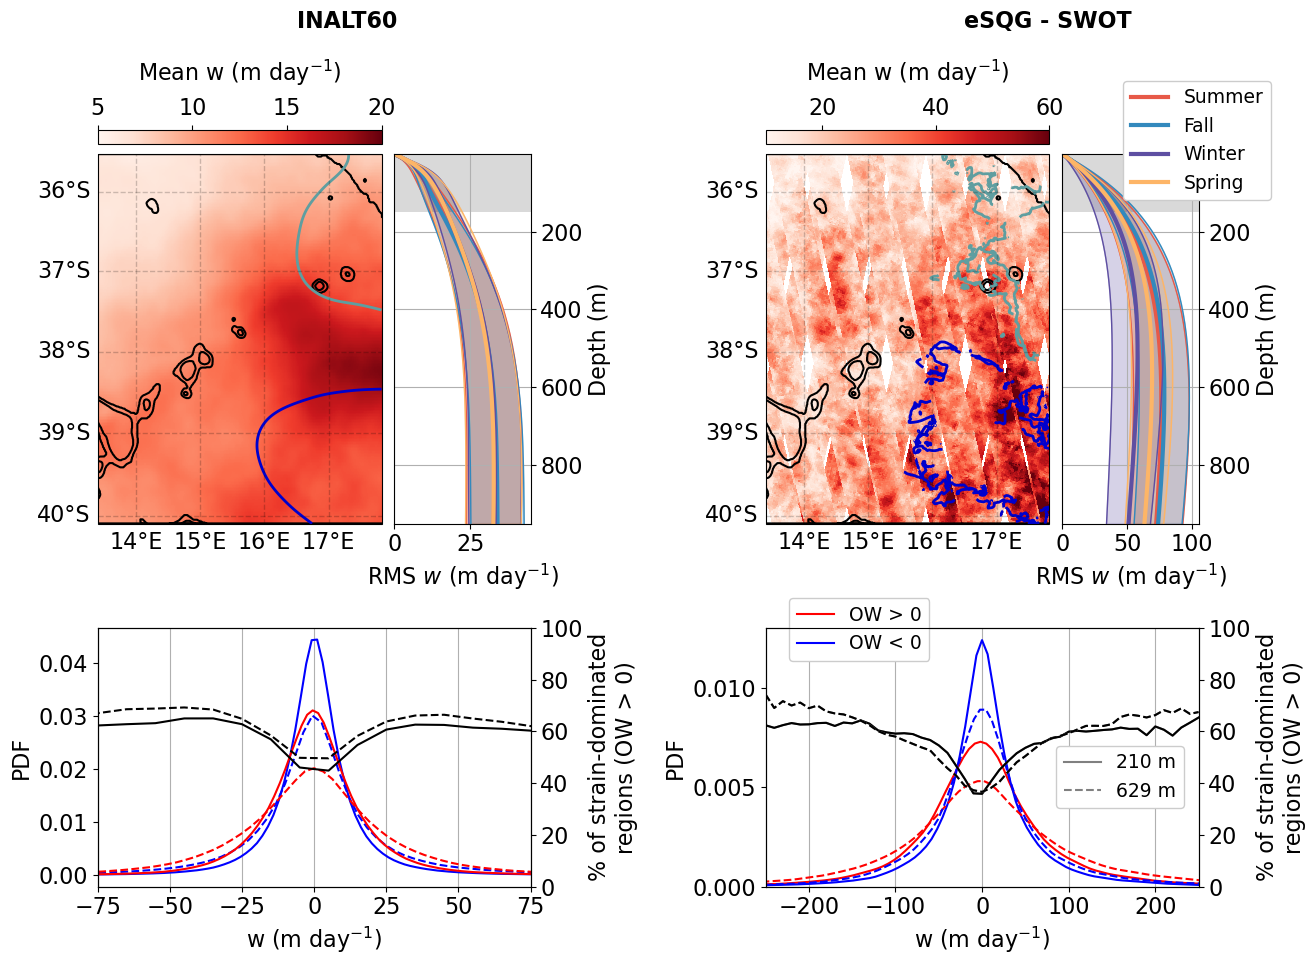

In [45]:
depth_id=47
ft=16

#Region set up
proj = ccrs.Mercator(central_longitude=(pos_west+pos_east)/2,min_latitude=pos_south,max_latitude=pos_north)
crs = ccrs.PlateCarree()
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent

#Start Figure
fig = plt.figure()

### SWOT reconstruction
    #Map w SWOT
axs=plt.axes(projection=proj)
axs.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor='darkseagreen')#,alpha=0.1)
axs.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
axs.set_extent(extent)
map_grid=axs.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = True
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft} 

axs.contour(bathy.nav_lon, bathy.nav_lat, bathy.bathy, transform=crs, levels=[3000,4000], colors='k')

pass_all = [305, 333, 361, 583, 27, 55, 320, 348, 376,14,42, 70]

for p in pass_all:    
    ds_maps = xr.open_dataset(path_save_data+'pass_number_'+str(p)+'.nc')
    data_w = ds_maps.w.isel(depth=depth_id).data
    im = axs.pcolormesh(ds_maps.lon, ds_maps.lat, np.nanmedian(abs(data_w), axis=0), cmap='Reds', vmin=10,vmax=60,transform=crs)

        #Add SSH contours
for p in [305, 27, 320, 348, 42]:
    ds_maps = xr.open_dataset(path_save_data+'ssh_'+str(p)+'.nc')
    if p==348:
        id_select = np.where(ds_maps.lat<-36.5)[0]
        ds_maps = ds_maps.isel(num_lines=id_select)
        axs.contour(ds_maps.lon, ds_maps.lat, np.nanmedian(ds_maps.ssh_store, axis=0)-spatial_mean, levels=[.15], colors='mediumblue',transform=crs, linestyles='solid', linewidths=2)
    else:
        axs.contour(ds_maps.lon, ds_maps.lat, np.nanmedian(ds_maps.ssh_store, axis=0)-spatial_mean, levels=[-.15], colors='cadetblue',transform=crs, linestyles='solid', linewidths=2)
        axs.contour(ds_maps.lon, ds_maps.lat, np.nanmedian(ds_maps.ssh_store, axis=0)-spatial_mean, levels=[.15], colors='mediumblue',transform=crs, linewidths=2)

        #Add colorbar
pos0=axs.get_position()
cax = fig.add_axes([pos0.x0, pos0.y0+pos0.height+0.02, pos0.width,0.03])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal')
cbar.set_label('Mean w (m day$^{-1}$)', fontsize=ft,labelpad=12)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft)

axs.text(16.5, -33.9, 'eSQG - SWOT', color='k', fontweight='semibold',fontsize=ft,transform=crs)

    #Seasonal RMS vertical profile
pos0=axs.get_position()
ax1=fig.add_axes([pos0.x0+pos0.width+.02, pos0.y0, pos0.width*.48, pos0.height])

RMS_files = [x for x in glob(path_save_data+'RMS_'+'*.nc')]
ds_rms = xr.open_mfdataset(RMS_files)

season_label = ['Summer', 'Fall', 'Winter', 'Spring']
n_lines = 20
cmap = mpl.colormaps['Spectral_r']

        # Take colors within the colormap.
color_list = cmap(np.linspace(0, 1, n_lines))[[16, 2, 0, 13],:]
month_list = [[12,1,2], [3,4,5], [6,7,8], [9,10,11]]

for m in range(4):
    ds_select = ds_rms.where(ds_rms.time.dt.month.isin(month_list[m]), drop=True)
    
    data = ds_select.RMS_velocity
    mean_profile = data.mean(dim='time').compute()
    env_5 = mean_profile - data.std(dim='time').compute()
    env_95 = mean_profile + data.std(dim='time').compute()
        
        # Plot mean profile
    ax1.plot(mean_profile, data.z, color=color_list[m], linewidth=3, label=season_label[m])
    ax1.plot(env_5, data.z, color=color_list[m], linewidth=1)
    ax1.plot(env_95, data.z, color=color_list[m], linewidth=1)
        #Fill in color between envelop
    x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
    y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
    ax1.fill(x,y,color=color_list[m], alpha=.25)

ax1.fill([0,300,300,0,0],[150, 150, 0, 0, 150],'k', alpha=.15)

ymin, ymax = data.z.isel(z=0), data.z.isel(z=-1)
vmin, vmax = 0, 105
ax1.set_ylim(ymin, ymax) 
ax1.set_xlim(vmin, vmax) 
ax1.set_xticks(np.arange(0,110, 50))
ax1.invert_yaxis()
ax1.set_xlabel('RMS $w$ (m day$^{-1}$)', fontsize=ft)
ax1.grid()
ax1.tick_params(axis='both',labelsize=ft)
ax1.set_ylabel('Depth (m)',fontsize=ft)
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()

ax1.legend(bbox_to_anchor=(.38, .85),framealpha=1, fontsize=ft-2.5)

    #Histogram w 
pos1=ax1.get_position()

ax3 = fig.add_axes([pos0.x0, pos0.y0-pos0.height*.8-.14, pos0.width+.02+pos1.width, pos0.height*.7])
ax03=ax3.twinx()
bins = np.arange(-250, 261, 10)
depth_id_list = np.array([36,54])

for depth_id, idd in zip(depth_id_list, np.arange(len(depth_id_list))):
    for p in range(len(pass_all)):
        ds_maps = xr.open_dataset(path_save_data+'pass_number_'+str(pass_all[p])+'.nc')
        ds_maps['OW'] = ds_maps.strain**2 - ds_maps.zeta**2
        ds_maps['OW_abs'] = abs(ds_maps.strain**2 - ds_maps.zeta**2)
    
        data_depth_select = ds_maps.isel(depth=depth_id_list[idd])
        
        thresh_OW = data_depth_select.OW_abs.quantile(0.7, dim=('cycle', 'num_lines', 'num_pixels')).values
       
        #Select points based on the thresholds
        abs_OW_flat = data_depth_select.OW_abs.data.flatten()
        OW_flat = data_depth_select.OW.data.flatten()
        w_flat = data_depth_select.w.data.flatten()
        
        #Remove nans
        id_select = np.where(np.isnan(w_flat)==0)[0]
        OW_flat=OW_flat[id_select]
        w_flat=w_flat[id_select]
        abs_OW_flat=abs_OW_flat[id_select]
        
        w_select = w_flat[np.where(abs_OW_flat>thresh_OW)[0]]
        OW_select = OW_flat[np.where(abs_OW_flat>thresh_OW)[0]]
        
        strain_structures = len(np.where(OW_select>0)[0])
    
        if p==0:
            OW_combine = OW_select
            w_combine = w_select
        else:
            OW_combine = np.concatenate([OW_combine, OW_select])
            w_combine = np.concatenate([w_combine, w_select])
    if idd==0:
        sns.kdeplot(w_combine[np.where(OW_combine>0)[0]], color='r', ax=ax3, label='OW > 0')
        sns.kdeplot(w_combine[np.where(OW_combine<0)[0]], color='b', ax=ax3, label='OW < 0')
    else:
        sns.kdeplot(w_combine[np.where(OW_combine>0)[0]], color='r', ax=ax3, linestyle='--')
        sns.kdeplot(w_combine[np.where(OW_combine<0)[0]], color='b', ax=ax3, linestyle='--')

    strain_ratio = np.zeros(len(bins)-1)
    for b in range(len(bins)-1):
        select_w=np.where((w_combine>bins[b]) & (w_combine<=bins[b+1]))[0]
        OW_select_w = OW_combine[select_w]
        sd = np.where(OW_select_w>0)[0]

        strain_ratio[b]=len(sd)/len(select_w) * 100
    if idd==0:
        ax03.plot(bins[:-1], strain_ratio, 'grey', label=str(np.round(ds_maps.isel(depth=depth_id).depth.values))[:3]+' m')
        ax03.plot(bins[:-1], strain_ratio, 'k')
    else:
        ax03.plot(bins[:-1], strain_ratio, 'grey', label=str(np.round(ds_maps.isel(depth=depth_id).depth.values))[:3]+' m',linestyle='--')
        ax03.plot(bins[:-1], strain_ratio, 'k',linestyle='--')

ax03.set_xlim([-250,250])

ax03.set_ylim([0,100])
ax3.grid(True, axis='x')
ax3.legend(bbox_to_anchor=(.4, 1.15), fontsize=ft-2.5,framealpha=1)
ax03.legend(bbox_to_anchor=(.65, .58), fontsize=ft-2.5,framealpha=1)
ax03.set_ylabel('% of strain-dominated\nregions (OW > 0)', fontsize=ft)
ax3.set_xlabel('w (m day$^{-1}$)', fontsize=ft)
ax3.set_ylabel('PDF', fontsize=ft)
ax3.tick_params(axis='both',labelsize=ft)
ax03.tick_params(axis='both',labelsize=ft)

### INALT60 fields
    #W map
ax30 = fig.add_axes([pos0.x0-pos0.width-.6, pos0.y0, pos0.width, pos0.height], projection=proj)
ax30.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor='darkseagreen')#,alpha=0.1)
ax30.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
ax30.set_extent(extent)
map_grid=ax30.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = True
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft} 
        #Bathymetry
ax30.contour(bathy.nav_lon, bathy.nav_lat, bathy.bathy, transform=crs, levels=[3000,4000], colors='k')
        #W
im = ax30.pcolormesh(map_model.longitude, map_model.latitude, map_model.w_model, cmap='Reds', vmin=5,vmax=20,transform=crs)
        #SSH contours
ax30.contour(ssh_model.longitude, ssh_model.latitude, ssh_model.ssh_model - np.mean(ssh_model.ssh_model), levels=[-.15], colors='cadetblue',transform=crs, linestyles='solid', linewidths=2)
ax30.contour(ssh_model.longitude, ssh_model.latitude, ssh_model.ssh_model - np.mean(ssh_model.ssh_model), levels=[.15], colors='mediumblue',transform=crs, linewidths=2)
ax30.text(16.5, -33.9, 'INALT60', color='k', fontweight='semibold',fontsize=ft,transform=crs)


pos3=ax30.get_position()
cax = fig.add_axes([pos3.x0, pos3.y0+pos3.height+0.02, pos3.width,0.03])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal')
cbar.set_label('Mean w (m day$^{-1}$)', fontsize=ft,labelpad=12)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft)

    #Seasonal RMS vertical profile
ax4=fig.add_axes([pos3.x0+pos3.width+.02, pos3.y0, pos3.width*.48, pos3.height])
RMS_model = xr.open_dataset(main_path+'Data_SWOT/RMS_w.nc')

for m in range(4):
    
        # Plot mean profile
    var_name= 'RMS_w_' + season_label[m]
    mean_profile = RMS_model[var_name]
    var_name= 'std_w_' + season_label[m]

    env_5 = mean_profile - RMS_model[var_name]
    env_95 = mean_profile + RMS_model[var_name]

    ax4.plot(mean_profile, data.z, color=color_list[m], linewidth=3, label=season_label[m])
    ax4.plot(env_5, data.z, color=color_list[m], linewidth=1)
    ax4.plot(env_95, data.z, color=color_list[m], linewidth=1)
    #Fill in color between envelop
    x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
    y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
    ax4.fill(x,y,color=color_list[m], alpha=.25)

ax4.fill([0,300,300,0,0],[150, 150, 0, 0, 150],'k', alpha=.15)

ymin, ymax = data.z.isel(z=0), data.z.isel(z=-1)
vmin, vmax = 0, 45
ax4.set_ylim(ymin, ymax) 
ax4.set_xlim(vmin, vmax) 
ax4.invert_yaxis()
ax4.set_xlabel('RMS $w$ (m day$^{-1}$)', fontsize=ft)
ax4.grid()
ax4.set_ylabel('Depth (m)', fontsize=ft)
ax4.tick_params(axis='both',labelsize=ft)
ax4.yaxis.set_label_position("right")
ax4.yaxis.tick_right()
    #Histogram w
pos03=ax03.get_position()
ax5 = fig.add_axes([pos3.x0, pos3.y0-pos3.height*.8-.14, pos03.width, pos03.height])
ax05=ax5.twinx()
ds_model = xr.open_dataset(files_OW[2])
ax5.plot(ds_model.x,ds_model.PDF, 'b')
ds_model = xr.open_dataset(files_OW[5])
ax5.plot(ds_model.x,ds_model.PDF, 'b', linestyle='--')
ds_model = xr.open_dataset(files_OW[1])
ax5.plot(ds_model.x,ds_model.PDF, 'r')
ds_model = xr.open_dataset(files_OW[4])
ax5.plot(ds_model.x,ds_model.PDF, 'r', linestyle='--')

ds_model = xr.open_dataset(files_OW[0])
ax05.plot(ds_model.bins,ds_model.ratio, 'k')
ds_model = xr.open_dataset(files_OW[3])
ax05.plot(ds_model.bins,ds_model.ratio, 'k--')

ax5.set_xlim([-75,75])
ax05.set_ylim([0,100])
ax5.grid(True, axis='x')
ax05.set_ylabel('% of strain-dominated\nregions (OW > 0)', fontsize=ft)
ax5.set_xlabel('w (m day$^{-1}$)', fontsize=ft)
ax5.set_ylabel('PDF', fontsize=ft)
ax5.tick_params(axis='both',labelsize=ft)
ax05.tick_params(axis='both',labelsize=ft)